# 具備 Memory 的 Agents

我們已經有一個 email assistant，它用 router 來對 email 進行 triage，然後把 email 交給 agent 產生回應。我們也已經評估過它，並加上了 human-in-the-loop（HITL）來審查特定的 tool calls。現在，我們要加上 memory，讓我們的 assistant 具備記住我們 HITL 回饋的能力！

![overview-img](img/overview_memory.png)

#### 載入環境變數

In [11]:
from dotenv import load_dotenv
load_dotenv("../.env")

True

## LangGraph 中的 Memory

### Thread-Scoped 與 Across-Thread Memory

首先，值得說明一下 [memory 在 LangGraph 中是如何運作的](https://langchain-ai.github.io/langgraph/concepts/memory/)。LangGraph 提供兩種各有用途、彼此互補的 memory 類型：

**Thread-Scoped Memory（短期）** 在單一對話 thread 的範圍內運作。它會作為 graph state 的一部分被自動管理，並透過 thread-scoped 的 checkpoints 加以持久化。這種 memory 類型會保留對話歷史、上傳的檔案、取回的文件，以及互動過程中產生的其他成果。可以把它想成一種工作記憶（working memory），在一段特定對話中維持情境，讓 agent 不必每次都從頭開始就能參照先前的訊息或動作。

**Across-Thread Memory（長期）** 則延伸到個別對話之外，建立一個橫跨多個 session 的持久知識庫。這種 memory 會以 JSON 文件的形式儲存在 memory store 中，依 namespaces（像資料夾）與不同的 keys（像檔名）加以組織。與 thread-scoped memory 不同，這些資訊即使在對話結束後仍會留存，讓系統能夠記住使用者的偏好、過去的決策，以及累積下來的知識。這正是讓 agent 能真正隨時間學習與調適、而非把每次互動都視為孤立事件的關鍵。

![short-vs-long-term-memory](img/short-vs-long.png)

[Store](https://langchain-ai.github.io/langgraph/reference/store/#langgraph.store.base.BaseStore) 是這個架構的基礎，提供一個彈性的資料庫，讓 memories 能被組織、取回與更新。這套做法之所以強大，在於無論你使用的是哪一種 memory 類型，同一個 Store 介面都提供一致的存取模式。這讓你的 agent 程式碼能保持不變，無論你在開發階段使用的是簡單的 in-memory 實作，或在部署時使用正式等級的資料庫。

### LangGraph Store

LangGraph 依你的[部署](https://langchain-ai.github.io/langgraph/tutorials/deployment/#other-deployment-options)方式，提供不同的 [Store 實作](https://langchain-ai.github.io/langgraph/reference/store/#langgraph.store.base.BaseStore)：

1. **In-Memory（例如 notebooks）**：
   - 使用 `from langgraph.store.memory import InMemoryStore`
   - 純粹是記憶體中的一個 Python dictionary，沒有持久化
   - 程序終止時資料就會遺失
   - 適合快速實驗與測試
   - 可以如[這裡](https://langchain-ai.github.io/langgraph/how-tos/memory/semantic-search/)所示設定語意搜尋

2. **用 `langgraph dev` 進行本機開發**：
   - 與 InMemoryStore 類似，但具有偽持久化（pseudo-persistence）
   - 資料會在重啟之間以 pickle 形式存到本機檔案系統
   - 輕量且快速，不需要外部資料庫
   - 可以如[這裡](https://langchain-ai.github.io/langgraph/cloud/deployment/semantic_search/)所示設定語意搜尋
   - 很適合開發，但並非為正式環境使用所設計

3. **LangGraph Platform 或正式環境部署**：
   - 使用搭配 pgvector 的 PostgreSQL，達到正式等級的持久化
   - 完全持久化的資料儲存，並有可靠的備份
   - 可擴展以應對較大的資料集
   - 可以如[這裡](https://langchain-ai.github.io/langgraph/cloud/deployment/semantic_search/)所示設定語意搜尋
   - 預設的距離度量是 cosine similarity（可自訂）

在這份 notebook 中，我們就使用 `InMemoryStore` 吧！

In [12]:
# ⭐ 本章的主角。整章讀不讀得懂，就看有沒有分清 Store 和 Checkpointer 的差別。
#
# Checkpointer（前幾章那個 InMemorySaver）= thread-scoped
#   存的是「這一次對話的過程」。掛在 thread_id 底下，換個 thread_id 就完全看不到。
# Store（本章這個 InMemoryStore）= across-thread
#   存的是「跨越所有對話的長期知識」。不綁 thread，任何 thread 都讀得到。
#
# 類比：checkpointer 是「這一局的存檔」，store 是「玩家帳號上的成就與設定」。
#   開新的一局（換 thread_id）→ 存檔重來，這局打到哪全部不見；
#   但帳號資料還在 → 你上一局解鎖的設定，這一局照樣生效。
#
# 這就是「使用者偏好」該放 store、而不是放 state 的原因：
# 偏好不屬於某一次對話，它屬於這個使用者本人。放進 state 的話，
# 對話一結束就跟著存檔一起被遺忘，下一封 email 又得重新教一次。
#
# ⚠️ 踩雷：InMemoryStore 是存在 RAM 裡的，kernel 一重啟就全部歸零，只適合教學。
#    上線要換成真正會持久化的 store（例如 PostgresStore），否則服務一重啟，
#    使用者教了三個月的偏好全部蒸發，而且不會有任何錯誤訊息。
from langgraph.store.memory import InMemoryStore
in_memory_store = InMemoryStore()

In [3]:
in_memory_store

Memories 會以一個 tuple 來劃分 namespace，在這個特定範例中會是 (`<user_id>`, "memories")。namespace 可以是任意長度、代表任何意義，並不一定要與使用者相關。

### 這句話到底在說什麼？—— namespace 就是「資料夾路徑」

上面那句「tuple、任意長度、任何意義、不一定跟使用者相關」讀起來很玄，其實它只是在描述一件很單純的事：

```python
store.put( ("kevin", "memories"),  "pref",  {"text": "Kevin 喜歡簡短的信"} )
#          └── 放哪個資料夾 ──┘   └檔名┘   └──── 檔案內容 ────┘
```

翻成檔案系統你就懂了：

| Store | 檔案系統 |
|---|---|
| `("kevin", "memories")` | `/kevin/memories/` 這個資料夾 |
| `store.put(ns, "pref", {...})` | 在那個資料夾裡存一個叫 `pref` 的檔 |
| `store.get(ns, "pref")` | 從那個資料夾把 `pref` 讀出來 |
| `store.search(("kevin",))` | `ls -R /kevin/` —— 把整個子樹撈出來 |

**namespace 是資料夾，key 是檔名，value 是內容。** 就這樣。

#### 拆解那三個形容詞

**「任意長度」** —— `("a",)` 一層可以，`("a","b","c","d")` 四層也可以。沒有規定要幾層，你想切多細就多細。

**「代表任何意義」** —— 這句才是重點：**LangGraph 根本不解讀你的 namespace**。`"kevin"` 對它來說不是「一個使用者」，就只是一段拿來比對的文字。它不會因為第一層叫 `kevin` 就做什麼特別的事。你要拿它分使用者、分功能、分租戶、分環境、分日期，它一律當字串處理。

**「不一定要與使用者相關」** —— 這句是教材在**自我預告**。它前一句才剛舉例 `(user_id, "memories")`，怕你以為 namespace 天生就是分使用者用的，所以先打預防針——因為**它自己接下來的程式碼一個 `user_id` 都沒有**，全部改用「功能」來分：

```python
("email_assistant", "triage_preferences")    # 哪些信該忽略
("email_assistant", "response_preferences")  # 回信的文筆偏好
("email_assistant", "cal_preferences")       # 排會議的習慣
```

三個抽屜都屬於同一個助理，跟「誰在用」無關。**因為這個 assistant 只服務一個人（Lance），要分開的不是「誰的偏好」，而是「哪一類偏好」。**

#### 為什麼是 tuple，不是 `"email_assistant/cal"` 這種字串？

**因為 tuple 有層級，可以照子樹搜尋。** 實測：

```
store.put(("kevin","memories"),              "pref", ...)   # 三個都叫 pref
store.put(("alice","memories"),              "pref", ...)
store.put(("email_assistant","cal_preferences"), "pref", ...)
→ 三筆完全不打架，因為資料夾不同

store.search(("email_assistant",))  → 撈到底下全部 2 筆（整個子樹）
store.search(("kevin",))            → 只撈到 kevin 的，不會混到 alice
```

字串做不到最後那件事——你得自己 split、自己比對前綴。而且用 `/` 當分隔符的話，`user_id` 本身含有 `/` 時就爆了。

> 💡 **實務上怎麼決定怎麼切？** 問自己「什麼情況下這兩筆資料絕對不能看到彼此」。多租戶產品 → 第一層放 `user_id`；只服務一個人的助理 → 拿來分功能（就是本章的做法）。真要兩者都要，就是 `(user_id, "email_assistant", "cal_preferences")` 三層——**這就是「任意長度」在實務上的用途**。

In [ ]:
# namespace 是 tuple 而不是字串——為什麼？因為它是「階層式」的命名空間，
# 就像資料夾路徑：("1", "memories") 讀作「1 號使用者的 memories 資料夾」。
# 每一層是 tuple 的一個元素，寫成 tuple 就不必自己處理「該用什麼字元分隔」
# 這種爛問題（若用 "/" 分隔，那 user_id 本身含有 "/" 時就爆了）。 -> 23/45/kevin/demo.txt -> 分不出 "/"
#
# 分層帶來的好處是天然隔離：("1", "memories") 和 ("2", "memories") 是兩個不同的抽屜，2 號使用者永遠撈不到 1 號的東西，你不必自己寫任何過濾邏輯。
# ⚠️ 這裡用 user_id 當第一層，只是本節「示範 store API」的舉例。
#    後面真正的 email assistant 用的是 ("email_assistant", "triage_preferences")
#    這種「用途別」分層——因為那個場景只服務一個使用者（Lance），
#    要分開的不是「誰的偏好」，而是「哪一類偏好」。
#    namespace 怎麼切完全由你決定，它只是資料夾，沒有規定第一層一定要是 user。
user_id = "1"
namespace_for_memory = (user_id, "memories")
# 等同於資料夾路徑：/1/memories/ 裡面放一份文件去儲存想記住的筆記 or... 記憶 

我們使用 `store.put` 方法把 memories 存到 store 中的 namespace。這麼做時，我們會指定如上所定義的 namespace，以及一組代表該 memory 的 key-value：key 只是該 memory 的唯一識別碼（memory_id），而 value（一個 dictionary）就是 memory 本身。

In [13]:
# store.put(namespace, key, value) 三件套：哪個抽屜、貼什麼標籤、放什麼東西。
#
# key 這裡用隨機 uuid → 每 put 一次就是「新增一筆」，舊的都留著（像日記，一天一篇）。
# 對照組：後面 email assistant 一律用固定的 key "user_preferences"，
# 同一個 key 重複 put 就變成「覆寫」→ 永遠只有一份、被不斷改寫的偏好設定檔。
# 同一個 put 方法，key 給隨機值是「累積」，給固定值是「更新」，差別只在 key 怎麼取。
import uuid
memory_id = str(uuid.uuid4())
memory = {"food_preference" : "I like pizza"}
in_memory_store.put(namespace_for_memory, memory_id, memory)

我們可以用 `store.search` 方法讀出 namespace 中的 memories，它會以一個 list 回傳某位使用者的所有 memories。最新的 memory 會是 list 中的最後一個。每個 memory 類型都是一個 Python class（`Item`），帶有若干屬性。我們可以透過 `.dict` 轉換，把它當作 dictionary 來存取。它所具備的屬性如下所示，而其中通常最重要的就是 `value`。

In [6]:
# 兩種讀法，用途不同：
#   store.get(namespace, key) → 點對點：我知道要哪一筆，直接拿（回傳單一物件，找不到給 None）
#   store.search(namespace)   → 整批撈：把這個資料夾裡的東西全部倒出來（回傳 list）
#
# ⚠️ 踩雷：get / search 回傳的不是你當初存進去的東西本身，而是包了一層的 Item 物件。
#    Item 上面有 namespace / key / value / created_at / updated_at 這些欄位，
#    你 put 進去的內容躺在 .value 裡面。
#    直接把回傳值當內容用（例如塞進 prompt），不會拋例外，只會讓 LLM 收到一坨
#    物件描述而不是資料——行為變差但你查不出原因，安靜出事的最難抓。
#    後面 get_memory() 裡那句 `user_preferences.value` 就是在剝這層殼。
memories = in_memory_store.search(namespace_for_memory)
memories[-1].dict()

{'namespace': ['1', 'memories'],
 'key': 'e5fcb7d9-2f8c-4763-ac8c-621e6138ac4c',
 'value': {'food_preference': 'I like pizza'},
 'created_at': '2026-07-17T07:31:53.428885+00:00',
 'updated_at': '2026-07-17T07:31:53.428886+00:00',
 'score': None}

In [7]:
memories

[Item(namespace=['1', 'memories'], key='e5fcb7d9-2f8c-4763-ac8c-621e6138ac4c', value={'food_preference': 'I like pizza'}, created_at='2026-07-17T07:31:53.428885+00:00', updated_at='2026-07-17T07:31:53.428886+00:00', score=None)]

要在 graph 中使用這一點，我們只需要用 store 來編譯 graph 即可：

In [14]:
# 兩個一起傳，不是二選一——它們負責的是完全不同的兩件事：
#   checkpointer → 讓這次對話「停得下來、續得回去」（HITL 的 interrupt 靠它）
#   store        → 讓跨對話的偏好「留得住」（本章的 memory 靠它）
# 少了 checkpointer，interrupt 完就回不來；少了 store，學到的偏好換個 thread 就消失。
# 本章的 email assistant 兩個都要，缺一不可。
from langgraph.checkpoint.memory import InMemorySaver
checkpointer = InMemorySaver()
from langgraph.store.memory import InMemoryStore
in_memory_store = InMemoryStore()
# 下面這行是註解掉的示意寫法，真正的編譯在後面的測試 cell
# graph = graph.compile(checkpointer=checkpointer, store=in_memory_store)

接著，這個 store 在 graph 的任何 node 中都可以存取，我們將在下面看到這一點！

## 為我們的 Assistant 加上 Memory

我們把先前那張具備 HITL 的 graph 拿來，為它加上 memory。這會和我們先前所做的非常相似。我們只需要在從使用者那裡取得回饋時，更新 store 中的 memory。

![overview-img](img/HITL_flow_memory.png)

### 「任何 node 都可以存取」—— 可是**怎麼**存取？

這句話跳過了本章最魔法的一步。你 `compile(store=...)` 之後，node 是這樣拿到 store 的：

```python
def triage_router(state: State, store: BaseStore):
    #                           └──────┬──────┘
    #              你從來沒有傳這個參數，它自己出現的
    user_prefs = store.get(("email_assistant", "triage_preferences"), "user_preferences")
```

**你不會在任何地方寫 `triage_router(state, store)` 去呼叫它。** LangGraph 看到這個 node 的函式簽章裡有一個叫 `store` 的參數，就自動把你 `compile(store=...)` 時給的那個實例塞進去。這叫**依賴注入**——參數自己從天而降。

#### 它到底靠什麼認出來？（實測）

| 你的函式簽章 | 結果 |
|---|---|
| `def n(state, store: BaseStore)` | ✅ 注入成功 |
| `def n(state, my_store: BaseStore)` | ❌ `TypeError: missing 1 required positional argument` |
| `def n(state, store: dict)` | ❌ `TypeError: missing 1 required positional argument` |
| `def n(state, store)`（不寫型別） | ✅ 注入成功 |

**參數必須叫 `store`，型別要嘛寫 `BaseStore`、要嘛不寫。** 名字取成 `my_store` 或型別標成 `dict`，LangGraph 就當作不認識它，於是那個參數沒人給值 → 直接 TypeError。

> ⚠️ **這是「隱形契約」**：靠名字和型別約定，不是靠設定。這在 LangGraph / LangSmith 生態裡到處都是（LangSmith 的 evaluator 也是靠參數名 `outputs` / `reference_outputs` 注入）。**看到一個沒有明顯來源的參數，先假設它是靠名字注入的。**

#### ⚠️ 最陰險的坑：`compile()` 忘記給 store

實測結果——**它不會報錯**：

```python
graph = builder.compile()          # 忘了 store=...
graph.invoke({...})                # 照跑不誤！
# 但 node 裡的 store 是 None
# → 等你呼叫 store.get(...) 時才炸：
#   AttributeError: 'NoneType' object has no attribute 'get'
```

錯誤訊息**一個字都不會提到 store**，只說某個 NoneType 沒有 `get` 方法。你會跑去檢查 namespace、檢查 key，最後才發現是 compile 那行少打了六個字。

> 💡 **順帶一提**：store 會**自動流進 sub-graph**。本章的 `response_agent` 是一張獨立編譯的 sub-graph、編譯時沒傳 store，但它裡面的 node 照樣拿得到外層那個 store。這就是為什麼教材能那樣寫而不用到處傳。

In [15]:

%load_ext autoreload
%autoreload 2

from typing import Literal
from datetime import datetime
from pydantic import BaseModel, Field

from langchain.chat_models import init_chat_model
from langchain_core.tools import tool

from langgraph.graph import StateGraph, START, END
from langgraph.store.base import BaseStore
from langgraph.types import interrupt, Command

from email_assistant.prompts import triage_system_prompt, triage_user_prompt, agent_system_prompt_hitl_memory, default_triage_instructions, default_background, default_response_preferences, default_cal_preferences, MEMORY_UPDATE_INSTRUCTIONS, MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT
from email_assistant.tools.default.prompt_templates import HITL_MEMORY_TOOLS_PROMPT
from email_assistant.schemas import State, RouterSchema, StateInput
from email_assistant.utils import parse_email, format_for_display, format_email_markdown

# Agent tools
@tool
def write_email(to: str, subject: str, content: str) -> str:
    """撰寫並寄出一封 email。"""
    # 佔位回應 - 真實應用中會實際寄出 email
    return f"Email sent to {to} with subject '{subject}' and content: {content}"

@tool
def schedule_meeting(
    attendees: list[str], subject: str, duration_minutes: int, preferred_day: datetime, start_time: int
) -> str:
    """在行事曆上排定一場會議。"""
    # 佔位回應 - 真實應用中會檢查行事曆並排程
    date_str = preferred_day.strftime("%A, %B %d, %Y")
    return f"Meeting '{subject}' scheduled on {date_str} at {start_time} for {duration_minutes} minutes with {len(attendees)} attendees"

@tool
def check_calendar_availability(day: str) -> str:
    """查詢某一天的行事曆空檔。"""
    # 佔位回應 - 真實應用中會檢查實際的行事曆
    return f"Available times on {day}: 9:00 AM, 2:00 PM, 4:00 PM"

@tool
class Question(BaseModel):
      """要詢問使用者的問題。"""
      content: str

@tool
class Done(BaseModel):
      """Email 已寄出。"""
      done: bool
    
# agent 可用的所有 tools
tools = [
    write_email, 
    schedule_meeting, 
    check_calendar_availability, 
    Question, 
    Done
]

tools_by_name = {tool.name: tool for tool in tools}

# 初始化要搭配 router / structured output 使用的 LLM
llm = init_chat_model("openai:gpt-4.1", temperature=0.0)
llm_router = llm.with_structured_output(RouterSchema) 

# 初始化 LLM，並強制 agent 使用 tool（任一可用的 tool）
llm = init_chat_model("openai:gpt-4.1", temperature=0.0)
llm_with_tools = llm.bind_tools(tools, tool_choice="required")

現在，這是關鍵的部分！我們目前在 graph 中並沒有捕捉任何來自使用者的回饋。

### Memory Management

我們*想*做的事其實相當直接：我們想把回饋加到 memory `Store` 中。如果我們用 `Store` 編譯 graph，就能在任何 node 中存取它。所以那不成問題！

但我們得回答兩個問題：

1) 我們想讓 memory 具有什麼樣的結構？
2) 我們想如何更新 memory？

對於 1)，為了讓事情保持簡單，我們就把 memories 存成字串。在下面這個函式中，我們會單純地從 store 把 memories 以字串形式取出，若不存在則以預設值初始化。

> 📖 **繁體中文對照**（下一格 `Markdown(default_triage_instructions)` 顯示的英文原文翻譯）
> 這是**分類規則**——告訴 agent 哪些信該回、哪些該通知、哪些該忽略。實際送進 LLM 的仍是英文原文，這裡只是幫你讀懂它在講什麼。

**不值得回覆的 email（→ ignore）：**
- 行銷電子報與促銷信
- 垃圾信或可疑信件
- 被 CC 在純知會（FYI）的討論串、且沒有直接問到你

**需要被知道、但不需要回信的（→ notify 通知）：**
- 團隊成員請病假或休假
- 建置系統通知或部署訊息
- 沒有待辦事項的專案進度更新
- 重要的公司公告
- 含有當前專案相關資訊的 FYI 信
- HR 部門的截止期限提醒
- 訂閱狀態／續訂提醒
- GitHub 通知

**值得回覆的 email（→ respond）：**
- 團隊成員需要專業判斷的直接提問
- 需要確認的會議邀請
- 與團隊專案相關的重大 bug 回報
- 管理層需要你回應確認的請求
- 客戶詢問專案狀態或功能
- 關於文件、程式碼或 API 的技術問題（尤其是缺少的 endpoint 或功能）
- 與家人相關的私人提醒（太太／女兒）
- 與自我照顧相關的私人提醒（看醫生等）

In [16]:
from rich.markdown import Markdown
Markdown(default_triage_instructions)

Emails that are not worth responding to:                                                                           

 • Marketing newsletters and promotional emails                                                                    
 • Spam or suspicious emails                                                                                       
 • CC'd on FYI threads with no direct questions                                                                    

There are also other things that should be known about, but don't require an email response. For these, you should 
notify (using the notify response). Examples of this include:                                                      

 • Team member out sick or on vacation                                                                             
 • Build system notifications or deployments                                                                       
 • Project status updates without action items                                                                     
 • Important company announcements                                                                                 
 • FYI emails that contain relevant information for current projects                                               
 • HR Department deadline reminders                                                                                
 • Subscription status / renewal reminders                                                                         
 • GitHub notifications                                                                                            

Emails that are worth responding to:                                                                               

 • Direct questions from team members requiring expertise                                                          
 • Meeting requests requiring confirmation                                                                         
 • Critical bug reports related to team's projects                                                                 
 • Requests from management requiring acknowledgment                                                               
 • Client inquiries about project status or features                                                               
 • Technical questions about documentation, code, or APIs (especially questions about missing endpoints or         
   features)                                                                                                       
 • Personal reminders related to family (wife / daughter)                                                          
 • Personal reminder related to self-care (doctor appointments, etc)

> 📖 **繁體中文對照**（下一格 `Markdown(default_cal_preferences)` 的英文原文翻譯；實際送進 LLM 的仍是英文）
> 這是 agent 排會議時的**行事曆偏好**，也是後面示範「memory 如何被回饋更新」時，會被改掉的那份初始資料。

偏好 30 分鐘的會議，但 15 分鐘的會議也可以接受。

In [17]:
Markdown(default_cal_preferences)

30 minute meetings are preferred, but 15 minute meetings are also acceptable.

> 📖 **繁體中文對照**（下一格 `Markdown(default_response_preferences)` 的英文原文翻譯；實際送進 LLM 的仍是英文）
> 這是 agent 寫回信時的**文筆與行為偏好**。後面你編輯草稿給回饋時，被更新的就是這一份。

使用專業、精簡的措辭。若信中提到截止期限，回覆時務必明確地確認並引用該期限。

**回覆需要調查的技術問題時：**
- 清楚說明你會親自調查、還是會去問誰
- 提供一個「何時會有更多資訊或完成任務」的預估時程

**回覆活動或研討會邀請時：**
- 一律確認信中提到的任何截止期限（尤其是報名期限）
- 若提到工作坊或特定主題，進一步詢問細節
- 若提到折扣（團體或早鳥），主動詢問相關資訊
- 不要當場做出承諾

**回覆協作或專案相關請求時：**
- 確認信中提到的既有成果或素材（草稿、投影片、文件等）
- 明確表示你會在會議前或會議中檢視這些素材
- 安排會議時，清楚說出你提議的具體日期、星期與時間

**回覆會議安排請求時：**
- 若對方提了時間，先核對所有被提到時段的行事曆空檔，再依你的空檔挑一個時間把會議排下去；或者說明你無法配合所提時間
- 若對方沒提時間，就查自己的行事曆，並在有空時提供多個時間選項，而不是只給一個
- 在回覆中提到會議時長，以確認你有正確記下
- 在回覆中引用這場會議的目的

In [18]:
Markdown(default_response_preferences)        

Use professional and concise language. If the e-mail mentions a deadline, make sure to explicitly acknowledge and  
reference the deadline in your response.                                                                           

When responding to technical questions that require investigation:                                                 

 • Clearly state whether you will investigate or who you will ask                                                  
 • Provide an estimated timeline for when you'll have more information or complete the task                        

When responding to event or conference invitations:                                                                

 • Always acknowledge any mentioned deadlines (particularly registration deadlines)                                
 • If workshops or specific topics are mentioned, ask for more specific details about them                         
 • If discounts (group or early bird) are mentioned, explicitly request information about them                     
 • Don't commit                                                                                                    

When responding to collaboration or project-related requests:                                                      

 • Acknowledge any existing work or materials mentioned (drafts, slides, documents, etc.)                          
 • Explicitly mention reviewing these materials before or during the meeting                                       
 • When scheduling meetings, clearly state the specific day, date, and time proposed                               

When responding to meeting scheduling requests:                                                                    

 • If times are proposed, verify calendar availability for all time slots mentioned in the original email and then 
   commit to one of the proposed times based on your availability by scheduling the meeting. Or, say you can't make
   it at the time proposed.                                                                                        
 • If no times are proposed, then check your calendar for availability and propose multiple time options when      
   available instead of selecting just one.                                                                        
 • Mention the meeting duration in your response to confirm you've noted it correctly.                             
 • Reference the meeting's purpose in your response.

In [19]:
# 「先 get，沒有就 put 一份預設值再回傳」——這是「第一次執行時初始化」的慣用寫法。
# 為什麼需要它？因為 store 一開始是空的，而 prompt 又非有內容不可。
# 有了它，node 就不必自己判斷「這是不是第一次跑」，無腦呼叫 get_memory 就對了：
# 第一次拿到預設值（順便寫進 store），之後拿到的是被使用者回饋改寫過的版本。
#
# 注意每個 namespace 裡都固定只用 "user_preferences" 這一個 key。
# 也就是每個抽屜裡永遠只有一份設定檔、被反覆覆寫——不是一筆筆累積的日記。
def get_memory(store, namespace, default_content=None):
    """從 store 取得 memory，若不存在則以預設值初始化。
    
    Args:
        store: 用來搜尋既有 memory 的 LangGraph BaseStore 實例
        namespace: 定義 memory namespace 的 tuple，例如 ("email_assistant", "triage_preferences")
        default_content: 當 memory 不存在時要使用的預設內容
        
    Returns:
        str: memory profile 的內容，來自既有 memory 或預設值
    """
    # get 找不到時回傳 None（不會拋例外），所以下面才能直接用 if 判斷有沒有
    user_preferences = store.get(namespace, "user_preferences")
    
    # ⚠️ 踩雷：這裡的 .value 不能省。get 回傳的是 Item 物件，不是你存的內容本身。
    #    忘了 .value 不會報錯，只會把一個 Item 物件塞進 prompt。
    if user_preferences:
        return user_preferences.value
    
    # 找不到 → 寫一份預設值進 store，順便回傳它。
    # 之所以要「順便寫進去」，是為了讓後面的 update_memory 有東西可以改
    # （它會直接讀既有的 profile，假設一定存在）。
    else:
        # Namespace、key、value
        store.put(namespace, "user_preferences", default_content)
        user_preferences = default_content
    
    # 回傳預設內容
    return user_preferences 

對於 2) 更新 memory，我們可以運用 [GPT-4.1 prompting guide](https://cookbook.openai.com/examples/gpt4-1_prompting_guide) 中的一些技巧來協助我們更新 memory：

* 為了達到最佳效果，把關鍵指示在 prompt 的開頭與結尾各重複一次
* 撰寫清楚、明確的指示
* 使用 XML 分隔符來建立結構
* 提供範例

> 📖 **繁體中文對照**（下一格 `Markdown(MEMORY_UPDATE_INSTRUCTIONS)` 的英文原文翻譯；**實際送進 LLM 的仍是英文原文**，這裡只幫你讀懂）
> 這是整章的靈魂：**它是叫 LLM「怎麼更新 memory」的指令**。重點只有一句——只做針對性的增修，絕不整份重寫。

**# 角色與目標**
你是一個 email assistant 的 memory profile 管理員，依據 human-in-the-loop 互動中的人類回饋，**選擇性地**更新使用者偏好。

**# 指令**
- 絕不覆寫整份 memory profile
- 只針對新資訊做**針對性的新增**
- 只更新那些被回饋**直接推翻**的特定事實
- 保留 profile 中所有其他既有資訊
- 格式與原本風格保持一致
- 把 profile 輸出成一個字串

**# 推理步驟**
1. 分析目前 memory profile 的結構與內容
2. 檢視 human-in-the-loop 互動的回饋訊息
3. 從回饋中萃取相關的使用者偏好（例如對信件／行事曆邀約的編輯、對 assistant 表現的明確回饋、使用者決定忽略某些信）
4. 拿新資訊與既有 profile 比對
5. 只找出要新增或更新的**特定**事實
6. 保留所有其他既有資訊
7. 輸出完整的更新後 profile

**# 範例**（原文用一個 `<memory_profile>` → `<user_messages>` → `<updated_profile>` 的例子，示範「只把 system admin notifications 從 RESPOND 移到 NOTIFY，其餘完全不動」——這是在教 LLM 輸出的格式與「最小改動」原則）

**# 佔位符**：`{namespace}` 與 `{current_profile}` 是 `.format()` 會填入的變數（分別是「哪個抽屜」和「目前的 profile 內容」）。⚠️ 翻譯或改寫時**絕對不能動這兩個大括號**，動了就 `KeyError`。

結尾要求 LLM「一步步想清楚：拿到的是什麼回饋、該新增或更新什麼，同時保留其他一切」。

In [20]:

Markdown(MEMORY_UPDATE_INSTRUCTIONS)

Role and Objective                                                 

You are a memory profile manager for an email assistant agent that selectively updates user preferences based on   
feedback messages from human-in-the-loop interactions with the email assistant.                                    

                                                   Instructions                                                    

 • NEVER overwrite the entire memory profile                                                                       
 • ONLY make targeted additions of new information                                                                 
 • ONLY update specific facts that are directly contradicted by feedback messages                                  
 • PRESERVE all other existing information in the profile                                                          
 • Format the profile consistently with the original style                                                         
 • Generate the profile as a string                                                                                

                                                  Reasoning Steps                                                  

 1 Analyze the current memory profile structure and content                                                        
 2 Review feedback messages from human-in-the-loop interactions                                                    
 3 Extract relevant user preferences from these feedback messages (such as edits to emails/calendar invites,       
   explicit feedback on assistant performance, user decisions to ignore certain emails)                            
 4 Compare new information against existing profile                                                                
 5 Identify only specific facts to add or update                                                                   
 6 Preserve all other existing information                                                                         
 7 Output the complete updated profile                                                                             

                                                      Example                                                      

<memory_profile> RESPOND:                                                                                          

 • wife                                                                                                            
 • specific questions                                                                                              
 • system admin notifications NOTIFY:                                                                              
 • meeting invites IGNORE:                                                                                         
 • marketing emails                                                                                                
 • company-wide announcements                                                                                      
 • messages meant for other teams </memory_profile>                                                                

<user_messages> "The assistant shouldn't have responded to that system admin notification." </user_messages>       

<updated_profile> RESPOND:                                                                                         

 • wife                                                                                                            
 • specific questions NOTIFY:                                                                                      
 • meeting invites                                                                                                 
 • system admin notifications IGNORE:                                                                              
 • marketing emails                                                                          

> 📖 **繁體中文對照**（下一格 `Markdown(MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT)` 的英文原文翻譯；實際送進 LLM 的仍是英文）
> 這段是上面那份指令的**濃縮重點**，會在每次更新 memory 的 user message 結尾**再貼一次**。為什麼要重貼？這是 GPT-4.1 prompting guide 的技巧：**關鍵指示在 prompt 的開頭與結尾各講一次，遵循度更高**（對抗「lost in the middle」）。

請記住：
- 絕不覆寫整份 memory profile
- 只針對新資訊做針對性的新增
- 只更新那些被回饋直接推翻的特定事實
- 保留 profile 中所有其他既有資訊
- 格式與原本風格保持一致
- 把 profile 輸出成一個字串

In [21]:
Markdown(MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT)

Remember:                                                                                                          

 • NEVER overwrite the entire memory profile                                                                       
 • ONLY make targeted additions of new information                                                                 
 • ONLY update specific facts that are directly contradicted by feedback messages                                  
 • PRESERVE all other existing information in the profile                                                          
 • Format the profile consistently with the original style                                                         
 • Generate the profile as a string

In [56]:
# ⭐ 本章的靈魂：memory 到底要怎麼「更新」？
#
# 直覺會想：把新回饋接在舊字串後面不就好了？不行。
# 使用者的回饋是自然語言（「寫短一點」「以後別排 45 分鐘」）。它可能是
# 「新增一條偏好」，也可能是「推翻既有的某一條」，還可能該被一般化成更廣的原則
# （把「這次改成 30 分鐘」讀成「他偏好 30 分鐘的會議」）。
# 這種「融合」只有 LLM 做得到，字串拼接做不到。
#
# 所以更新 memory 的做法是：再叫一次 LLM。
#   輸入：現有的 profile（放 system prompt）+ 這次發生的事（messages）
#   輸出：更新後的完整 profile
# 相當於請一位編輯：「這是舊稿，這是使用者的意見，請你改出新稿。」
#
# ⚠️ 代價一定要講給學員聽：人類每給一次回饋，就多一次 LLM 呼叫。
#    HITL 的每個 edit / response / ignore 都要付這筆錢與延遲，天下沒有白吃的記憶。
class UserPreferences(BaseModel):
    """根據使用者回饋更新後的 user preferences。"""
    # chain_of_thought 擺在 user_preferences 前面不是隨便排的：
    # structured output 是照欄位順序生成的，先寫理由等於逼 LLM「先想再改」，
    # 而且這段理由會出現在 LangSmith trace 裡，memory 為什麼變成這樣一目瞭然。
    chain_of_thought: str = Field(description="Reasoning about which user preferences need to add / update if required")
    user_preferences: str = Field(description="Updated user preferences")

def update_memory(store, namespace, messages):
    """更新 store 中的 memory profile。
    
    Args:
        store: 用來更新 memory 的 LangGraph BaseStore 實例
        namespace: 定義 memory namespace 的 tuple，例如 ("email_assistant", "triage_preferences")
        messages: 用來更新 memory 的 messages 清單
    """

    # 取得既有的 memory
    user_preferences = store.get(namespace, "user_preferences")

    # 舊 profile 塞進 system prompt，「這次發生的事」接在後面當對話內容。
    # MEMORY_UPDATE_INSTRUCTIONS 的重點是叫 LLM「只做針對性的增修，不要整份重寫」——
    # 因為輸出的是整份 profile，不特別約束的話，LLM 很容易順手把舊偏好弄丟。
    #
    # ⚠️ 踩雷：下面那句 user_preferences.value 等於假設「memory 一定已經存在」。
    #    能這樣寫，是因為呼叫它的 node 之前一定先跑過 get_memory 完成初始化。
    #    你若自己新增一個 namespace，沒先 get_memory 就直接 update_memory，
    #    這行會炸 AttributeError: 'NoneType' object has no attribute 'value'。
    llm = init_chat_model("openai:gpt-4.1", temperature=0.0).with_structured_output(UserPreferences)
    result = llm.invoke(
        [
            {"role": "system", "content": MEMORY_UPDATE_INSTRUCTIONS.format(current_profile=user_preferences.value, namespace=namespace)},
        ] + messages
    )
    
    # 同一個 key 再 put 一次 = 覆寫，新 profile 取代舊 profile。
    # 從這裡寫進去的東西，下次 triage_router / llm_call 用 get_memory 就會讀到——
    # 「人類糾正 → agent 變聰明」這條迴路，就是在這一行接起來的。
    store.put(namespace, "user_preferences", result.user_preferences)

我們像之前一樣設定 triage router，只做一個小小的更動

In [22]:
# ⚠️ 學員一定會問：「我從頭到尾沒把 store 傳給這個函式，它哪來的？」
#
# 答案：LangGraph 會自動注入。你在 compile(store=...) 給的那個 store，
# 會被自動塞進任何「參數名叫 store」且「型別註記寫 BaseStore」的 node。
#
# 實測過的注入規則（名稱與型別兩個條件要同時成立，缺一不可）：
#   def f(state, store: BaseStore)     → 注入 ✅
#   def f(state, my_store: BaseStore)  → 不注入 ❌ 名字不對 → TypeError: missing argument
#   def f(state, store: dict)          → 不注入 ❌ 型別不對 → TypeError: missing argument
#   def f(state, store)                → 注入 ✅（沒寫註記也算，但別這樣寫，看不出意圖）
# 同一套機制也適用 writer: StreamWriter。這不是 store 專屬的魔法，而是 LangGraph
# 的「靠簽名要東西」慣例：node 想要什麼就在簽名上宣告，不必從 graph 頂層層層傳進來。
#
# ⚠️ 踩雷（安靜出事）：compile() 時忘了給 store 的話，這個參數不會報錯，
#    而是被塞一個 None 進來。要等到 node 裡真的去用它，才炸
#    AttributeError: 'NoneType' object has no attribute 'get'。
#    錯誤訊息完全不會提到「你忘了傳 store」——看到這個先回去檢查 compile()。
def triage_router(state: State, store: BaseStore) -> Command[Literal["triage_interrupt_handler", "response_agent", "__end__"]]:
    """分析 email 內容，判斷我們應該回覆、通知、還是忽略。

    triage 步驟可避免 assistant 把時間浪費在：
    - 行銷 email 與垃圾信
    - 全公司性的公告
    - 給其他團隊的訊息
    """
    # 解析 email 輸入
    author, to, subject, email_thread = parse_email(state["email_input"])
    user_prompt = triage_user_prompt.format(
        author=author, to=to, subject=subject, email_thread=email_thread
    )

    # 為 Agent Inbox 製作 email markdown，以備需要通知時使用
    email_markdown = format_email_markdown(subject, author, to, email_thread)

    # ⭐ 這是本章相對第 4 章 HITL 版，在 triage_router 裡唯一的改動：
    # 分類規則不再寫死成 default_triage_instructions，而是先問 store。
    # 第一次跑拿到預設值；之後拿到的是被人類回饋改寫過的版本 → 分類行為就跟著變。
    triage_instructions = get_memory(store, ("email_assistant", "triage_preferences"), default_triage_instructions)

    # 對照：background 就是直接用常數，沒有經過 store——因為它不是會被學習的東西。
    # （這也是後面 display_memory_content 裡 "background" 那個 namespace
    #   永遠顯示 "No memory found" 的原因，不是壞掉。）
    system_prompt = triage_system_prompt.format(
        background=default_background,
        triage_instructions=triage_instructions,
    )

    # 執行 router LLM
    result = llm_router.invoke(
        [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ]
    )

    # 判斷結果
    classification = result.classification

    # 處理分類判斷的結果
    if classification == "respond":
        print("📧 Classification: RESPOND - This email requires a response")
        # 下一個 node
        goto = "response_agent"
        # 更新 state
        update = {
            "classification_decision": result.classification,
            "messages": [{"role": "user",
                            "content": f"Respond to the email: {email_markdown}"
                        }],
        }
        
    elif classification == "ignore":
        print("🚫 Classification: IGNORE - This email can be safely ignored")

        # 下一個 node
        goto = END
        # 更新 state
        update = {
            "classification_decision": classification,
        }

    elif classification == "notify":
        print("🔔 Classification: NOTIFY - This email contains important information") 

        # 下一個 node
        goto = "triage_interrupt_handler"
        # 更新 state
        update = {
            "classification_decision": classification,
        }

    else:
        raise ValueError(f"Invalid classification: {classification}")
    
    return Command(goto=goto, update=update)

我們只需要對 interrupt handler 做一個小更動，好在使用者提供回饋時更新 memory。

In [23]:
# 回饋 → memory 的第一條線：使用者對「分類」本身有意見時。
# 這個 node 只會在系統判 notify（只通知、不回覆）時跑到。
def triage_interrupt_handler(state: State, store: BaseStore) -> Command[Literal["response_agent", "__end__"]]:
    """處理 triage 步驟產生的 interrupts"""
    
    # 解析 email 輸入
    author, to, subject, email_thread = parse_email(state["email_input"])

    # 為 Agent Inbox 製作 email markdown，以備需要通知時使用
    email_markdown = format_email_markdown(subject, author, to, email_thread)

    # 建立 messages
    messages = [{"role": "user",
                "content": f"Email to notify user about: {email_markdown}"
                }]

    # 為 Agent Inbox 建立 interrupt
    request = {
        "action_request": {
            "action": f"Email Assistant: {state['classification_decision']}",
            "args": {}
        },
        "config": {
            "allow_ignore": True,  
            "allow_respond": True,
            "allow_edit": False, 
            "allow_accept": False,  
        },
        # 要在 Agent Inbox 中顯示的 email
        "description": email_markdown,
    }

    # 送往 Agent Inbox 並等待回應
    response = interrupt([request])[0]

    # 若使用者提供回饋，前往 response agent，並利用回饋來回覆 email
    if response["type"] == "response":
        # 把回饋加入 messages
        user_input = response["args"]
        messages.append({"role": "user",
                        "content": f"User wants to reply to the email. Use this feedback to respond: {user_input}"
                        })
        # 系統判 notify，人類卻說「這封要回」→ 代表分類規則錯了。
        # 所以寫進 triage_preferences（分類規則），而不是回信風格。
        # 這條 memory 下次會流回 triage_router 的 system prompt，同類 email 就會直接判 respond。
        update_memory(store, ("email_assistant", "triage_preferences"), [{
            "role": "user",
            "content": f"The user decided to respond to the email, so update the triage preferences to capture this."
        }] + messages)

        goto = "response_agent"

    # 若使用者忽略 email，前往 END
    elif response["type"] == "ignore":
        # 反方向的同一件事：系統判 notify，人類連通知都不想收 → 一樣是分類規則要改。
        # 注意這則 message 是「特地寫給 memory LLM 看的指令」，不是使用者真的講的話。
        # 人類只是按了一個按鈕，要餵給 LLM 學，得先把這個動作翻譯成它看得懂的敘述。
        messages.append({"role": "user",
                        "content": f"The user decided to ignore the email even though it was classified as notify. Update triage preferences to capture this."
                        })
        
        # 這是新增的：用回饋更新 triage_preferences
        update_memory(store, ("email_assistant", "triage_preferences"), messages)
        goto = END

    # 攔截所有其他回應
    else:
        raise ValueError(f"Invalid response: {response}")

    # 更新 state
    update = {
        "messages": messages,
    }

    return Command(goto=goto, update=update)

### 把 Memory 納入 LLM 的回應

既然我們已經設定好 memory managers，就可以在產生回應時運用所儲存的偏好

In [26]:
# ⭐ 迴路的另一半：memory 在這裡被「讀出來」，回頭影響 LLM。
#
#   上一輪人類的糾正 → update_memory 寫進 store
#     → 這裡 get_memory 撈出來 → 塞進 system prompt → LLM 這次的行為就變了。
#
# 這裡有個一定要講的前提，不講學員會以為背後有什麼玄機：
# 所謂「agent 學會了」，沒有任何模型權重被更新，也沒有 fine-tune。
# 純粹就是 prompt 裡多了幾行字而已。
# memory 的本質 = 一段「會被自動維護的 prompt 內容」，如此而已。
def llm_call(state: State, store: BaseStore):
    """由 LLM 決定要不要呼叫 tool"""

    # 兩個 namespace 分開存，是因為它們會被不同的回饋改到：
    # 改 schedule_meeting → 學到 cal_preferences；改 write_email → 學到 response_preferences。
    # 混在一起的話，「會議要 30 分鐘」和「信要寫短一點」會互相污染。
    cal_preferences = get_memory(store, ("email_assistant", "cal_preferences"), default_cal_preferences)
    
    # 搜尋既有的 response_preferences memory
    response_preferences = get_memory(store, ("email_assistant", "response_preferences"), default_response_preferences)

    return {
        "messages": [
            llm_with_tools.invoke(
                [
                    {"role": "system", "content": agent_system_prompt_hitl_memory.format(tools_prompt=HITL_MEMORY_TOOLS_PROMPT,
                                                                                         background=default_background,
                                                                                         response_preferences=response_preferences, 
                                                                                         cal_preferences=cal_preferences)}
                ]
                + state["messages"]
            )
        ]
    }

### Interrupt Handler 中的 Memory 整合

同樣地，我們也會為 interrupt handler 加上 memory！

In [27]:
# ⭐ 整個系列的終點：人類的糾正，是怎麼變成 agent 的長期記憶的。
#
#   ┌─ Agent Inbox：人類看到 agent 想做的事，四選一 ────────────┐
#   │  accept   → 照原樣執行            → memory 不變 ✗          │
#   │  edit     → 人類親手改 args       → update_memory ✓        │
#   │  response → 人類用自然語言指正    → update_memory ✓        │
#   │  ignore   → 人類根本不想理這封    → update_memory ✓        │
#   └──────────────────────────┬─────────────────────────────────┘
#                              │ 只有「帶糾正」的三種會寫 memory
#                              ▼
#                   update_memory(store, namespace, ...)
#                     （再叫一次 LLM，把回饋融進舊 profile）
#                              │
#                              ▼
#                     store（across-thread，不綁 thread）
#                              │  下一封 email，甚至換一個 thread
#                              ▼
#            get_memory → 塞進 system prompt → LLM 的行為改變
#
# 為什麼 accept 不寫 memory？因為 accept 沒有提供任何「你哪裡做錯了」的訊號。
# agent 只從糾正中學習——這正是後面三組測試要親眼驗證的事。
#
# 回饋類型 → 寫進哪個抽屜，這個對應要記住：
#   edit / response 針對 write_email      → response_preferences（回信風格）
#   edit / response 針對 schedule_meeting → cal_preferences（排程偏好）
#   ignore 任何東西                        → triage_preferences（分類規則）
# 邏輯是：「做得不對」的糾正 → 改做事的偏好；
#        「根本不該做」的糾正 → 改「要不要出手」的分類規則。
def interrupt_handler(state: State, store: BaseStore) -> Command[Literal["llm_call", "__end__"]]:
    """建立 interrupt，讓人工審查 tool calls"""
    
    # 暫存 messages
    result = []

    # 接下來前往 LLM call node
    goto = "llm_call"

    # 逐一處理最後一則 message 中的 tool calls
    for tool_call in state["messages"][-1].tool_calls:
        
        # 允許進行 HITL 的 tools
        hitl_tools = ["write_email", "schedule_meeting", "Question"]
        
        # 若 tool 不在我們的 HITL 清單中，直接執行、不中斷
        if tool_call["name"] not in hitl_tools:

            # 不中斷直接執行 tool
            tool = tools_by_name[tool_call["name"]]
            observation = tool.invoke(tool_call["args"])
            result.append({"role": "tool", "content": observation, "tool_call_id": tool_call["id"]})
            continue
            
        # 從 state 的 email_input 取得原始 email
        email_input = state["email_input"]
        author, to, subject, email_thread = parse_email(email_input)
        original_email_markdown = format_email_markdown(subject, author, to, email_thread)
        
        # 格式化 tool call 以供顯示，並在前面附上原始 email
        tool_display = format_for_display(tool_call)
        description = original_email_markdown + tool_display

        # 設定 Agent Inbox 中允許哪些操作
        if tool_call["name"] == "write_email":
            config = {
                "allow_ignore": True,
                "allow_respond": True,
                "allow_edit": True,
                "allow_accept": True,
            }
        elif tool_call["name"] == "schedule_meeting":
            config = {
                "allow_ignore": True,
                "allow_respond": True,
                "allow_edit": True,
                "allow_accept": True,
            }
        elif tool_call["name"] == "Question":
            config = {
                "allow_ignore": True,
                "allow_respond": True,
                "allow_edit": False,
                "allow_accept": False,
            }
        else:
            raise ValueError(f"Invalid tool call: {tool_call['name']}")

        # 建立 interrupt request
        request = {
            "action_request": {
                "action": tool_call["name"],
                "args": tool_call["args"]
            },
            "config": config,
            "description": description,
        }

        # 送往 Agent Inbox 並等待回應
        response = interrupt([request])[0]

        # 處理各種回應
        if response["type"] == "accept":

            # 對照組：accept 只執行 tool，全程沒有任何 update_memory。
            # 人類按 accept = 「你做得對」，沒有糾正 → 沒東西可學。
            tool = tools_by_name[tool_call["name"]]
            observation = tool.invoke(tool_call["args"])
            result.append({"role": "tool", "content": observation, "tool_call_id": tool_call["id"]})
                        
        elif response["type"] == "edit":

            # 選擇 tool
            tool = tools_by_name[tool_call["name"]]
            # 這個要留著：等一下要拿「agent 原本寫的」和「人類改成的」做對照，
            # 學習訊號就藏在兩者的「差異」裡。
            initial_tool_call = tool_call["args"]
            
            # 從 Agent Inbox 取得編輯後的 args
            edited_args = response["args"]["args"]

            # 用編輯後的內容更新 AI message 的 tool call（指向 state 中的該則 message）
            ai_message = state["messages"][-1] # 從 state 取得最新的一則 message
            current_id = tool_call["id"] # 儲存正在編輯的那個 tool call 的 ID
            
            # 建立新的 tool calls 清單：濾掉正在編輯的那一個，再加入更新後的版本
            # 這樣可避免直接修改原始清單（不可變的作法）
            updated_tool_calls = [tc for tc in ai_message.tool_calls if tc["id"] != current_id] + [
                {"type": "tool_call", "name": tool_call["name"], "args": edited_args, "id": current_id}
            ]

            # 建立一份帶有更新後 tool calls 的 message 副本，而非修改原本的 message
            # 這能確保 state 的不可變性，並避免影響程式碼的其他部分
            # 當我們更新 messages 這個 state key（"messages": result）時，add_messages reducer 會
            # 依 id 覆寫既有的 messages，我們在此正是利用這個機制來更新 tool calls。
            result.append(ai_message.model_copy(update={"tool_calls": updated_tool_calls}))

            # 將回饋存入 memory，並用 Agent Inbox 編輯後的內容更新 write_email 的 tool call
            if tool_call["name"] == "write_email":
                
                # 用編輯後的 args 執行 tool
                observation = tool.invoke(edited_args)
                
                # 只加入 tool 回應的 message
                result.append({"role": "tool", "content": observation, "tool_call_id": current_id})

                # ⭐ 學習訊號在「差異」裡：initial_tool_call（agent 原本寫的）和
                # edited_args（人類改成的）「一起」餵給 LLM，讓它自己看出差在哪、
                # 再一般化成一條偏好（「45 被改成 30」→「他偏好 30 分鐘的會議」）。
                # 只給改完的結果是學不到東西的——沒有對照，就沒有訊號。
                update_memory(store, ("email_assistant", "response_preferences"), [{
                    "role": "user",
                    "content": f"User edited the email response. Here is the initial email generated by the assistant: {initial_tool_call}. Here is the edited email: {edited_args}. Follow all instructions above, and remember: {MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT}."
                }])
            
            # 將回饋存入 memory，並用 Agent Inbox 編輯後的內容更新 schedule_meeting 的 tool call
            elif tool_call["name"] == "schedule_meeting":
                
                # 用編輯後的 args 執行 tool
                observation = tool.invoke(edited_args)
                
                # 只加入 tool 回應的 message
                result.append({"role": "tool", "content": observation, "tool_call_id": current_id})

                # 同一套「前後對照」，只是改 schedule_meeting → 學到的是排程偏好，
                # 所以寫進 cal_preferences 這個抽屜。
                # 結尾又把 MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT 重貼一次，不是複製貼上出錯：
                # 關鍵指示在 prompt 的頭尾各講一次，LLM 比較不會忘（GPT-4.1 prompting guide 的建議）。
                update_memory(store, ("email_assistant", "cal_preferences"), [{
                    "role": "user",
                    "content": f"User edited the calendar invitation. Here is the initial calendar invitation generated by the assistant: {initial_tool_call}. Here is the edited calendar invitation: {edited_args}. Follow all instructions above, and remember: {MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT}."
                }])
            
            # 攔截所有其他 tool calls
            else:
                raise ValueError(f"Invalid tool call: {tool_call['name']}")

        elif response["type"] == "ignore":

            # ignore 三個分支一律寫 triage_preferences，不碰 response/cal_preferences。
            # 因為「我不想回這封信」是分類的問題（一開始就不該判 respond），
            # 不是「信寫得不好」的問題。寫錯抽屜的話，agent 會學成「回信要更小心」，
            # 而不是「這種信根本別回」——學到的東西完全走偏。
            if tool_call["name"] == "write_email":
                # 不執行 tool，並告訴 agent 接下來該怎麼做
                result.append({"role": "tool", "content": "User ignored this email draft. Ignore this email and end the workflow.", "tool_call_id": tool_call["id"]})
                # 前往 END
                goto = END
                # 這是新增的：更新 memory
                update_memory(store, ("email_assistant", "triage_preferences"), state["messages"] + result + [{
                    "role": "user",
                    "content": f"The user ignored the email draft. That means they did not want to respond to the email. Update the triage preferences to ensure emails of this type are not classified as respond. Follow all instructions above, and remember: {MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT}."
                }])

            elif tool_call["name"] == "schedule_meeting":
                # 不執行 tool，並告訴 agent 接下來該怎麼做
                result.append({"role": "tool", "content": "User ignored this calendar meeting draft. Ignore this email and end the workflow.", "tool_call_id": tool_call["id"]})
                # 前往 END
                goto = END
                # 這是新增的：更新 memory
                update_memory(store, ("email_assistant", "triage_preferences"), state["messages"] + result + [{
                    "role": "user",
                    "content": f"The user ignored the calendar meeting draft. That means they did not want to schedule a meeting for this email. Update the triage preferences to ensure emails of this type are not classified as respond. Follow all instructions above, and remember: {MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT}."
                }])

            elif tool_call["name"] == "Question":
                # 不執行 tool，並告訴 agent 接下來該怎麼做
                result.append({"role": "tool", "content": "User ignored this question. Ignore this email and end the workflow.", "tool_call_id": tool_call["id"]})
                # 前往 END
                goto = END
                # 這是新增的：更新 memory
                update_memory(store, ("email_assistant", "triage_preferences"), state["messages"] + result + [{
                    "role": "user",
                    "content": f"The user ignored the Question. That means they did not want to answer the question or deal with this email. Update the triage preferences to ensure emails of this type are not classified as respond. Follow all instructions above, and remember: {MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT}."
                }])

            else:
                raise ValueError(f"Invalid tool call: {tool_call['name']}")

        elif response["type"] == "response":
            # response 和 edit 的差別：edit 是「我幫你改好了」，response 是「你自己改」。
            # 注意這裡 tool 不會被執行，只是把回饋當成 tool message 塞回去，
            # 讓下一輪 llm_call 帶著這句話重寫一次。
            user_feedback = response["args"]
            if tool_call["name"] == "write_email":
                # 不執行 tool，並加入一則帶有使用者回饋的 message，以便納入 email 中
                result.append({"role": "tool", "content": f"User gave feedback, which can we incorporate into the email. Feedback: {user_feedback}", "tool_call_id": tool_call["id"]})
                # 這是新增的：更新 memory
                update_memory(store, ("email_assistant", "response_preferences"), state["messages"] + result + [{
                    "role": "user",
                    "content": f"User gave feedback, which we can use to update the response preferences. Follow all instructions above, and remember: {MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT}."
                }])

            elif tool_call["name"] == "schedule_meeting":
                # 不執行 tool，並加入一則帶有使用者回饋的 message，以便納入 email 中
                result.append({"role": "tool", "content": f"User gave feedback, which can we incorporate into the meeting request. Feedback: {user_feedback}", "tool_call_id": tool_call["id"]})
                # 這是新增的：更新 memory
                update_memory(store, ("email_assistant", "cal_preferences"), state["messages"] + result + [{
                    "role": "user",
                    "content": f"User gave feedback, which we can use to update the calendar preferences. Follow all instructions above, and remember: {MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT}."
                }])

            elif tool_call["name"] == "Question":
                # ⚠️ 注意這裡的不對稱：write_email / schedule_meeting 的 response 都會寫 memory，
                #    只有 Question 的 response「不寫」。這是刻意的——使用者回答
                #    「我想約在 X 餐廳」是這封信的事實，不是一條該長期記住的偏好。
                #    「什麼該進 memory、什麼只是這次的情境」，是設計 memory 系統時最難的判斷，
                #    抓錯的話 memory 會被一堆一次性瑣事塞爆，反而拖垮 agent。
                result.append({"role": "tool", "content": f"User answered the question, which can we can use for any follow up actions. Feedback: {user_feedback}", "tool_call_id": tool_call["id"]})

            else:
                raise ValueError(f"Invalid tool call: {tool_call['name']}")

    # 更新 state
    update = {
        "messages": result,
    }

    return Command(goto=goto, update=update)

其餘部分都和之前一樣！

/var/folders/px/22qqx_qn399gggmw1gsvgk000000gn/T/ipykernel_68510/1735499132.py:43: LangGraphDeprecatedSinceV05: `input` is deprecated and will be removed. Please use `input_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  StateGraph(State, input=StateInput)


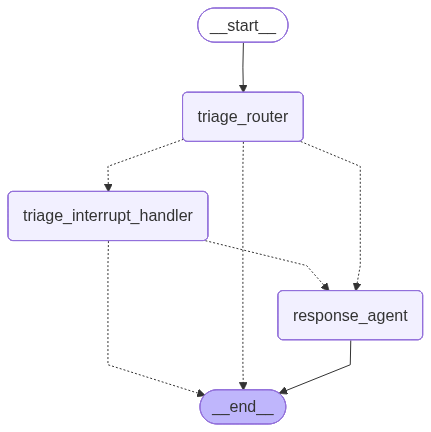

In [28]:
from email_assistant.utils import show_graph

# Conditional edge 函式
# 註：這個函式的簽名雖然宣告了 store，函式內卻完全沒用到——留著無害
# （LangGraph 照樣會注入），屬於原始教材的贅筆，不必模仿。
def should_continue(state: State, store: BaseStore) -> Literal["interrupt_handler", END]:
    """路由到 tool handler，若呼叫了 Done tool 則結束"""
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        for tool_call in last_message.tool_calls: 
            if tool_call["name"] == "Done":
                return END
            else:
                return "interrupt_handler"

# 建立 workflow
agent_builder = StateGraph(State)

# 加入 nodes - 帶有 store 參數
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("interrupt_handler", interrupt_handler)

# 加入 edges
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "interrupt_handler": "interrupt_handler",
        END: END,
    },
)

# ⚠️ 這個 subgraph 編譯時「沒有」傳 store，但它裡面的 llm_call / interrupt_handler
# 卻都拿得到 store。為什麼？因為 store 是透過 config 往下傳的：
# 外層 compile(store=...) 給的 store 會自動流進所有 subgraph 的 node。
# subgraph 不必、也不該自己再宣告一次（實測過，確實會傳進去）。
response_agent = agent_builder.compile()

# 用 store 與 checkpointer 建立整體 workflow
overall_workflow = (
    StateGraph(State, input=StateInput)
    .add_node(triage_router)
    .add_node(triage_interrupt_handler)
    .add_node("response_agent", response_agent)
    .add_edge(START, "triage_router")
)

# ⚠️ 踩雷：這裡的 compile() 同樣沒傳 store 和 checkpointer，這樣沒事——
#    因為它只拿去 show_graph() 畫圖，從來沒被 invoke 過。
#    真的要跑的版本在後面的測試 cell，那裡才有 compile(checkpointer=..., store=...)。
#    你若手癢對這個 email_assistant 呼叫 invoke，會炸
#    AttributeError: 'NoneType' object has no attribute 'get'——就是 store 是 None。
email_assistant = overall_workflow.compile()
show_graph(email_assistant)

## 測試具備 memory 的 agent

既然我們已經把 memory 實作進 email assistant，接下來就來測試這個系統如何從使用者回饋中學習、並隨時間調適。這個測試章節將探討不同類型的使用者互動如何造成不同的 memory 更新，進而提升 assistant 未來的表現。

我們透過這些測試想回答的關鍵問題是：
1. 系統如何捕捉並儲存使用者的偏好？
2. 這些儲存下來的偏好如何影響未來的決策？
3. 哪些互動模式會導致哪些類型的 memory 更新？

首先，我們來建一個輔助函式來顯示 memory 的內容，好讓我們能追蹤它在整個測試過程中如何演變：

In [29]:
import uuid 
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command
from langgraph.store.memory import InMemoryStore

# 純教學用的輔助函式：把 store 裡的東西印出來，好讓我們「看見」memory 有沒有變。
# 接下來三組測試（accept / edit / response）都會反覆呼叫它做前後對照。
#
# ⚠️ 原始教材的小陷阱：下面列的四個 namespace 裡，("email_assistant", "background")
#    永遠會印出 "No memory found"。不是壞掉、也不是你跑錯——background 從頭到尾
#    都是直接用常數 default_background，沒有任何一行程式碼會把它寫進 store。
#    （官方 src/email_assistant/email_assistant_hitl_memory.py 裡還留著一行 TODO
#      寫「這裡可以更新 background memory」，也就是預留欄位但沒實作。）
#    上課時先講一句，否則學員會在這裡卡住找 bug。
def display_memory_content(store, namespace=None):
    # 顯示所有 namespaces 目前的 memory 內容
    print("\n======= CURRENT MEMORY CONTENT =======")
    if namespace:
        memory = store.get(namespace, "user_preferences")
        if memory:
            print(f"\n--- {namespace[1]} ---")
            # 又是 .value：get 回傳的是 Item 物件，內容在 .value 裡
            print(memory.value)
        else:
            print(f"\n--- {namespace[1]} ---")
            print("No memory found")
    else:
        for namespace in [
            ("email_assistant", "triage_preferences"),
            ("email_assistant", "response_preferences"),
            ("email_assistant", "cal_preferences"),
            ("email_assistant", "background")
        ]:
            memory = store.get(namespace, "user_preferences")
            if memory:
                print(f"\n--- {namespace[1]} ---")
                print(memory.value)
            else:
                print(f"\n--- {namespace[1]} ---")
                print("No memory found")
            print("=======================================\n")

### 接受（Accept）`write_email` 與 `schedule_meeting`

我們的第一個測試檢視當使用者未做任何修改就接受 agent 的動作時，會發生什麼事。這個基準案例有助於我們理解在沒有提供回饋時，系統的行為：

1. 我們會使用和先前測試相同的那封稅務規劃 email
2. 系統會把它分類為 "RESPOND"，並提議安排一場會議
3. 我們會不做更動就接受這個會議排程
4. agent 會產生一封確認會議的 email
5. 我們會不做更動就接受這封 email

這個測試示範了我們這個具備 memory 的系統的預設行為。當使用者單純接受所提議的動作時，由於沒有可供學習的明確回饋，我們預期 memory 的更新會很少、甚至沒有。不過，系統在產生回應時，仍會運用既有的 memory（如果有的話）。

In [30]:
# Respond - 會議邀約的 email
email_input_respond = {
    "to": "Lance Martin <lance@company.com>",
    "author": "Project Manager <pm@client.com>",
    "subject": "Tax season let's schedule call",
    "email_thread": "Lance,\n\nIt's tax season again, and I wanted to schedule a call to discuss your tax planning strategies for this year. I have some suggestions that could potentially save you money.\n\nAre you available sometime next week? Tuesday or Thursday afternoon would work best for me, for about 45 minutes.\n\nRegards,\nProject Manager"
}

# ⭐ 每組測試情境都重新 InMemoryStore()——三組測試（accept / edit / response）
# 各自從「完全空白的記憶」開始，互不污染。
#
# 為什麼非這樣不可？因為我們要驗證的是「這一種回饋造成了什麼改變」。
# 如果沿用上一組測試的 store，memory 裡早就有 edit 學到的東西，
# 你就分不清眼前這個變化到底是誰造成的。等於每做一次實驗就換一組乾淨的對照組。
#
# 順帶注意 checkpointer 也一起重建、thread_id 也換新的：
# store 清空 = 忘掉所有長期偏好；thread 換新 = 忘掉這次對話。兩個維度同時歸零。
checkpointer = MemorySaver()
store = InMemoryStore()
graph = overall_workflow.compile(checkpointer=checkpointer, store=store)
thread_id_1 = uuid.uuid4()
thread_config_1 = {"configurable": {"thread_id": thread_id_1}}

# 執行 graph 直到第一次 interrupt
# email 會被分類為 "respond"
# agent 會建立 schedule_meeting 與 write_email 的 tool call
print("Running the graph until the first interrupt...")
for chunk in graph.stream({"email_input": email_input_respond}, config=thread_config_1):
    # 若有 interrupt 物件則加以檢視
    if '__interrupt__' in chunk:
        Interrupt_Object = chunk['__interrupt__'][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# 這是基準線：此時還沒有任何人類回饋，所以印出來的是 get_memory 剛寫進去的「預設值」。
# 先把這個畫面記住，等一下要跟兩次 accept 之後的畫面比對。
display_memory_content(store)

Running the graph until the first interrupt...
📧 Classification: RESPOND - This email requires a response

INTERRUPT OBJECT:
Action Request: {'action': 'schedule_meeting', 'args': {'attendees': ['pm@client.com', 'lance@company.com'], 'subject': 'Tax Planning Strategies Discussion', 'duration_minutes': 45, 'preferred_day': '2026-07-21', 'start_time': 14}}

======= CURRENT MEMORY CONTENT =======

--- triage_preferences ---

Emails that are not worth responding to:
- Marketing newsletters and promotional emails
- Spam or suspicious emails
- CC'd on FYI threads with no direct questions

There are also other things that should be known about, but don't require an email response. For these, you should notify (using the `notify` response). Examples of this include:
- Team member out sick or on vacation
- Build system notifications or deployments
- Project status updates without action items
- Important company announcements
- FYI emails that contain relevant information for current projects
-

接受 `schedule_meeting` 的 tool call

當我們檢視初始的 `schedule_meeting` 提案時，請注意系統如何運用既有的 memory 來輔助它的決策：

1. 預設的行事曆偏好顯示偏好 30 分鐘的會議，儘管這封 email 要求的是 45 分鐘
2. agent 仍然提議一場 45 分鐘的會議，以尊重寄件者的具體要求
3. 我們不做修改就接受這個提案，看看單純的接受是否會觸發任何 memory 更新

執行完這個步驟後，我們會檢查 memory 的內容，以確認單純的接受是否會導致 memory 更新。單純的接受代表了基準的使用者體驗 — 系統如預期般運作，而不需要任何調整。

In [31]:
print(f"\nSimulating user accepting the {Interrupt_Object.value[0]['action_request']['action']} tool call...")
for chunk in graph.stream(Command(resume=[{"type": "accept"}]), config=thread_config_1):
    # 若有 interrupt 物件則加以檢視
    if '__interrupt__' in chunk:
        Interrupt_Object = chunk['__interrupt__'][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")


Simulating user accepting the schedule_meeting tool call...

INTERRUPT OBJECT:
Action Request: {'action': 'write_email', 'args': {'to': 'pm@client.com', 'subject': "Re: Tax season let's schedule call", 'content': "Hello,\n\nThank you for reaching out. I am available on Tuesday, July 21st at 2:00 PM for a 45-minute call to discuss tax planning strategies. I look forward to hearing your suggestions and exploring ways to optimize this year's tax planning.\n\nPlease let me know if you need anything from me in advance of our meeting.\n\nBest regards,\nLance"}}


接受 `write_email` 的 tool call

現在我們會接受這封確認會議排程的 email 草稿：

1. 這封 email 草稿是在知道我們行事曆偏好的情況下產生的
2. 它包含了關於會議時間、時長與目的的細節
3. 我們會不做更動就接受它，以完成這個基準測試案例

接受之後，我們會檢查所有的 memory store，看看是否發生了任何更新。如同預期，單純接受 agent 的提案並不會提供強烈的學習訊號 — 因為對於使用者喜歡或不喜歡 agent 做法的哪些部分，並沒有明確的回饋。

trace 連結會顯示完整的 workflow 執行過程，我們可以在其中看到 memory 被用於產生回應的 LLM 呼叫中，但並未發生 memory 更新，而這正是單純接受時所預期的行為。

In [32]:
print(f"\nSimulating user accepting the {Interrupt_Object.value[0]['action_request']['action']} tool call...")
for chunk in graph.stream(Command(resume=[{"type": "accept"}]), config=thread_config_1):
    # 檢視 response_agent 最新的一則 message
    if 'response_agent' in chunk:
        chunk['response_agent']['messages'][-1].pretty_print()
    # 若有 interrupt 物件則加以檢視
    if '__interrupt__' in chunk:
        Interrupt_Object = chunk['__interrupt__'][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# ⭐ 對照組的結論就在這裡：印出來的 memory 跟上面那條基準線「一模一樣」。
# 兩次 accept（schedule_meeting 一次、write_email 一次），memory 一個字都沒變。
# 這就證明了 agent 只從糾正中學習——你說「對」它學不到東西，
# 你說「不對，應該這樣」它才學得到。
# 注意 memory 還是有被「用」到（LLM 產生回應時讀了它），只是沒有被「改」。
# 讀 memory ≠ 寫 memory，這兩件事要分開看。
display_memory_content(store)


Simulating user accepting the write_email tool call...
================================== Ai Message ==================================
Tool Calls:
  Done (call_Vg8EUYoa3dKc2iu3ZjxwLHf8)
 Call ID: call_Vg8EUYoa3dKc2iu3ZjxwLHf8
  Args:
    done: True

======= CURRENT MEMORY CONTENT =======

--- triage_preferences ---

Emails that are not worth responding to:
- Marketing newsletters and promotional emails
- Spam or suspicious emails
- CC'd on FYI threads with no direct questions

There are also other things that should be known about, but don't require an email response. For these, you should notify (using the `notify` response). Examples of this include:
- Team member out sick or on vacation
- Build system notifications or deployments
- Project status updates without action items
- Important company announcements
- FYI emails that contain relevant information for current projects
- HR Department deadline reminders
- Subscription status / renewal reminders
- GitHub notifications

Emails

我們可以看看完整的訊息，以及 trace：

https://smith.langchain.com/public/86ff6474-29fe-452e-8829-b05a91b458eb/r

你會注意到 memory 被用於產生回應的 LLM 呼叫中。

但是 memory store 並*沒有*被更新，因為我們並未透過 HITL 加入任何回饋。

In [33]:
# 這裡讀的是 checkpointer（這個 thread 的對話過程），不是 store。
# get_state → thread 的 state；display_memory_content → store 的長期偏好。
# 兩條線各存各的，這個 cell 正好可以拿來對照本章開頭講的
# thread-scoped（存檔）vs across-thread（帳號資料）。
state = graph.get_state(thread_config_1)
for m in state.values['messages']:
    m.pretty_print()

================================ Human Message =================================

Respond to the email: 

**Subject**: Tax season let's schedule call
**From**: Project Manager <pm@client.com>
**To**: Lance Martin <lance@company.com>

Lance,

It's tax season again, and I wanted to schedule a call to discuss your tax planning strategies for this year. I have some suggestions that could potentially save you money.

Are you available sometime next week? Tuesday or Thursday afternoon would work best for me, for about 45 minutes.

Regards,
Project Manager

---

================================== Ai Message ==================================
Tool Calls:
  check_calendar_availability (call_4oF572LHfXOGlTAXt4pj5rUH)
 Call ID: call_4oF572LHfXOGlTAXt4pj5rUH
  Args:
    day: 2026-07-21
  check_calendar_availability (call_yYoQzeCzJ0ZxtHvuJ34C4ftb)
 Call ID: call_yYoQzeCzJ0ZxtHvuJ34C4ftb
  Args:
    day: 2026-07-23
================================= Tool Message =================================

Ava

### 編輯（Edit）`write_email` 與 `schedule_meeting`

這個測試探討系統如何從對其所提議動作的直接編輯中學習。當使用者修改 agent 的建議時，便會產生關於其偏好的明確、具體的學習訊號：

1. 我們會使用和之前相同的那封稅務規劃 email
2. 當 agent 提議一場 45 分鐘的會議時，我們會把它編輯為：
   - 把時長改為 30 分鐘（與我們儲存的偏好一致）
   - 把主旨行改得更精簡
3. 當 agent 草擬一封 email 時，我們會把它編輯為：
   - 更簡短、更不正式
   - 採用不同的結構

編輯能提供關於使用者偏好最明確的回饋，讓系統能精確地學到使用者想要哪些更動。我們預期會看到 memory store 出現具體、針對性的更新，以反映這些編輯。

In [ ]:
# 與先前相同的 email
email_input_respond = {
    "to": "Lance Martin <lance@company.com>",
    "author": "Project Manager <pm@client.com>",
    "subject": "Tax season let's schedule call",
    "email_thread": "Lance,\n\nIt's tax season again, and I wanted to schedule a call to discuss your tax planning strategies for this year. I have some suggestions that could potentially save you money.\n\nAre you available sometime next week? Tuesday or Thursday afternoon would work best for me, for about 45 minutes.\n\nRegards,\nProject Manager"
}

# 第二組測試。同一封 email、同一套流程，唯一的變因是人類這次選 edit 而不是 accept。
# store 重新建立、thread 換新 → 又是一組乾淨的對照組（理由同上一組）。
checkpointer = MemorySaver()
store = InMemoryStore()
graph = overall_workflow.compile(checkpointer=checkpointer, store=store)
thread_id_2 = uuid.uuid4()
thread_config_2 = {"configurable": {"thread_id": thread_id_2}}

# 執行 graph 直到第一次 interrupt - 會被分類為 "respond"，且 agent 會建立一個 write_email 的 tool call
print("Running the graph until the first interrupt...")
for chunk in graph.stream({"email_input": email_input_respond}, config=thread_config_2):
    # 若有 interrupt 物件則加以檢視
    if '__interrupt__' in chunk:
        Interrupt_Object = chunk['__interrupt__'][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# 這次只看 cal_preferences 一個 namespace（等一下要改 schedule_meeting）。基準線。
display_memory_content(store,("email_assistant", "cal_preferences"))

編輯 `schedule_meeting` 的 tool call

當我們編輯會議提案時，我們便是在提供關於自身偏好的直接、明確的回饋。這為系統創造了一個重要的學習機會：

1. agent 最初提議一場 45 分鐘的會議（這封 email 所要求的時長）
2. 我們把它編輯為 30 分鐘，並把主旨從「Tax Planning Strategies Discussion」簡化為「Tax Planning Discussion」
3. 這便產生了關於我們時間偏好與命名慣例的明確、具體的回饋

編輯之後，我們會檢查行事曆偏好的 memory store，看看它是如何被更新的。這次的 memory 更新應該同時捕捉到：
- 我們偏好較短的 30 分鐘會議
- 我們偏好更精簡的會議主旨

trace 揭示了精確的 memory 更新邏輯，顯示系統如何分析它的提案與我們的編輯之間的差異，藉以萃取出有意義的模式與偏好。我們可以看到每次 memory 更新的詳細理由，確保學習過程的透明度。

In [ ]:
# 這次差在哪：人類把 45 分鐘改成 30 分鐘。
# 這只是「一次」具體的編輯，但等一下 memory 印出來會變成一條
# 「他偏好 30 分鐘會議」的一般性原則——把單一事件一般化成偏好的這個動作，
# 就是 update_memory 裡那次 LLM 呼叫做的，不是任何規則寫死的。
print("\nSimulating user editing the schedule_meeting tool call...")
edited_schedule_args = {
    "attendees": ["pm@client.com", "lance@company.com"],
    "subject": "Tax Planning Discussion",
    "duration_minutes": 30, # 由 45 改為 30
    "preferred_day": "2025-04-22",
    "start_time": 14 
}
for chunk in graph.stream(Command(resume=[{"type": "edit", "args": {"args": edited_schedule_args}}]), config=thread_config_2):
    # 檢視 response_agent 最新的一則 message
    if 'response_agent' in chunk:
        chunk['response_agent']['messages'][-1].pretty_print()
    # 若有 interrupt 物件則加以檢視
    if '__interrupt__' in chunk:
        Interrupt_Object = chunk['__interrupt__'][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# 和上面的基準線比對：這次 memory 變了。edit 有糾正 → 學得到東西。
print("\nChecking memory after editing schedule_meeting:")
display_memory_content(store,("email_assistant", "cal_preferences"))

```
{'preferences': '\n30 minute meetings are preferred, but 15 minute meetings are also acceptable.\n'}
```

```
{'preferences': "30 minute meetings are preferred, but 15 minute meetings are also acceptable.\n\nUser prefers 30 minute meetings over longer durations such as 45 minutes. When scheduling, default to 30 minutes unless otherwise specified. Subject lines should be concise (e.g., 'Tax Planning Discussion' instead of 'Tax Planning Strategies Discussion')."}
```

看看編輯行事曆邀約之後的 memory，我們可以看到它已經被更新了：

1. 系統已辨識出我們偏好 30 分鐘的會議勝過較長的時長
2. 它也捕捉到我們偏好精簡的會議主旨

這次 memory 更新特別令人印象深刻的地方在於：
- 它不只記錄了我們的具體編輯，更一般化為一個更廣泛的偏好模式
- 它在加入新資訊的同時，保留了所有既有的 memory 內容
- 它從單一一次編輯互動中萃取出多個偏好訊號

現在，我們來編輯 email 草稿，看看系統如何捕捉不同類型的溝通偏好：

In [ ]:
# 這次差在哪：改的是 write_email → 所以會寫進 response_preferences，不是 cal_preferences。
# 先印一次當基準線，跑完再印一次，同一個 namespace 的前後差異就一目瞭然。
display_memory_content(store,("email_assistant", "response_preferences"))
# 現在模擬使用者編輯 write_email 的 tool call
print("\nSimulating user editing the write_email tool call...")
edited_email_args = {
    "to": "pm@client.com",
    "subject": "Re: Tax season let's schedule call",
    "content": "Thanks! I scheduled a 30-minute call next Thursday at 3:00 PM. Would that work for you?\n\nBest regards,\nLance Martin"
}
for chunk in graph.stream(Command(resume=[{"type": "edit", "args": {"args": edited_email_args}}]), config=thread_config_2):
    # 檢視 response_agent 最新的一則 message
    if 'response_agent' in chunk:
        chunk['response_agent']['messages'][-1].pretty_print()
    # 若有 interrupt 物件則加以檢視
    if '__interrupt__' in chunk:
        Interrupt_Object = chunk['__interrupt__'][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# 在編輯 write_email 後檢查 memory
print("\nChecking memory after editing write_email:")
display_memory_content(store,("email_assistant", "response_preferences"))

我們對 email 的編輯揭示了更為精細的學習能力：

1. 我們大幅縮短並簡化了 email 的內容
2. 我們把語氣改得更隨性
3. 我們加上了一個請求對方確認的問題，而非逕自假定時間可行
4. 我們略微更動了會議的細節（日期與時間）

看看更新後的 memory，我們可以看到系統已萃取出一項關於我們溝通風格的關鍵洞見：

```
When scheduling a meeting, ask the recipient to confirm if the proposed time works for them, rather than assuming and stating the meeting is already scheduled.
```

這示範了系統的能力：
- 不只在表面層次分析我們的編輯，更能理解其意圖
- 從具體的範例中萃取出可一般化的原則
- 在加入新洞見的同時保留所有既有的指引
- 維持 memory 的組織與結構

這些針對性、高品質的 memory 更新，將會在不需要反覆修正的情況下，改善未來所有的互動。

In [ ]:
state = graph.get_state(thread_config_2)
for m in state.values['messages']:
    m.pretty_print()

### 以回饋回應（Respond with feedback）`write_email` 與 `schedule_meeting`

我們最後這組測試探討「response」這種回饋模式 — 提供指引，而不直接編輯或接受。這種對話式的回饋機制提供了介於接受與編輯之間的折衷做法：

1. 首先，我們會測試針對會議排程的回饋，要求：
   - 較短的時長（30 分鐘而非 45 分鐘）
   - 下午的會議時間（2pm 之後）
   
2. 接著，我們會測試針對 email 草擬的回饋，要求：
   - 更簡短、更不正式的措辭
   - 一句關於期待這場會議的特定結尾語句
   
3. 最後，我們會測試針對問題的回饋，提供：
   - 一個帶有額外情境的直接答案
   - 具體的偏好（早午餐地點、時間）

這種自然語言的回饋做法，讓使用者能引導 assistant，而不必親自動手完成工作。我們預期會看到詳細的 memory 更新，從我們具體的回饋中萃取出一般性的原則。

In [ ]:
# Respond - 會議邀約的 email
email_input_respond = {
    "to": "Lance Martin <lance@company.com>",
    "author": "Project Manager <pm@client.com>",
    "subject": "Tax season let's schedule call",
    "email_thread": "Lance,\n\nIt's tax season again, and I wanted to schedule a call to discuss your tax planning strategies for this year. I have some suggestions that could potentially save you money.\n\nAre you available sometime next week? Tuesday or Thursday afternoon would work best for me, for about 45 minutes.\n\nRegards,\nProject Manager"
}

# 第三組測試。這次人類不動手改，只用自然語言講「我想要什麼」。
# 對照組的意義：edit 是「我幫你改好了」，response 是「你自己改」。
# 兩者都算糾正、都會寫 memory——要看的重點是：response 這種比較模糊的回饋，
# 能不能萃取出跟 edit 一樣具體的偏好？（實務上這很重要：手機上打字改 args 很痛苦，
# 但講一句「短一點」很容易。這條路走得通，HITL 才有機會被真的用起來。）
# 老規矩，store 重建、thread 換新。
checkpointer = MemorySaver()
store = InMemoryStore()
graph = overall_workflow.compile(checkpointer=checkpointer, store=store)
thread_id_5 = uuid.uuid4()
thread_config_5 = {"configurable": {"thread_id": thread_id_5}}

# 執行 graph 直到第一次 interrupt
# email 會被分類為 "respond"
# agent 會建立 schedule_meeting 與 write_email 的 tool call
print("Running the graph until the first interrupt...")
for chunk in graph.stream({"email_input": email_input_respond}, config=thread_config_5):
    # 若有 interrupt 物件則加以檢視
    if '__interrupt__' in chunk:
        Interrupt_Object = chunk['__interrupt__'][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# 基準線
display_memory_content(store, ("email_assistant", "cal_preferences"))

為 `schedule_meeting` 的 tool call 提供回饋

我們不直接編輯會議提案、也不單純接受它，而是提供自然語言的回饋：

1. 我們要求一場 30 分鐘的會議，而非 45 分鐘
2. 我們表達偏好下午 2pm 之後的會議
3. 系統必須詮釋這份回饋，並產生一份新的提案

這種對話式的做法往往比直接編輯更自然、更有效率，對於行動裝置使用者、或偏好給予高層次方向而非詳細編輯的人來說尤其如此。

提供回饋之後，我們會檢視行事曆偏好的 memory，看看這份自然語言指引是如何被捕捉的。我們預期系統會把會議時長與一天當中的時段偏好，都萃取為一般性的原則。

In [ ]:
# 這次差在哪：一句自然語言同時夾帶了「兩個」偏好（時長 30 分鐘 + 時段 2pm 後）。
# 看下面 memory 會不會兩個都抓到，而且不會把既有的偏好洗掉。
print(f"\nSimulating user providing feedback for the {Interrupt_Object.value[0]['action_request']['action']} tool call...")
for chunk in graph.stream(Command(resume=[{"type": "response", "args": "Please schedule this for 30 minutes instead of 45 minutes, and I prefer afternoon meetings after 2pm."}]), config=thread_config_5):
    # 若有 interrupt 物件則加以檢視
    if '__interrupt__' in chunk:
        Interrupt_Object = chunk['__interrupt__'][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# 在為 schedule_meeting 提供回饋後檢查 memory
print("\nChecking memory after providing feedback for schedule_meeting:")
display_memory_content(store, ("email_assistant", "cal_preferences"))

我們在提供回饋之後檢查 memory，看到一次優雅而簡潔的行事曆偏好更新：

```
30 minute meetings are preferred, but 15 minute meetings are also acceptable.
Afternoon meetings after 2pm are preferred.
```

系統已經：
1. 捕捉到我們回饋的兩個面向（時長與一天當中的時段）
2. 保留了既有關於 15 分鐘會議的偏好
3. 把我們偏好下午 2pm 之後會議的偏好作為新的一行加入
4. 讓格式維持乾淨且易讀

這種自然語言的回饋機制，創造出與直接編輯同等品質的 memory 更新，卻只需要使用者付出更少的心力。系統能從非結構化的回饋中萃取出結構化的偏好，展現了它從對話式互動中學習的能力。

我們來接受這份修訂後的會議提案，然後進到 email 草稿：

In [ ]:
# 這次差在哪：給完回饋之後才 accept。
# accept 一樣不寫 memory——偏好在上一步的 response 就已經學走了，這裡只是放行而已。
print(f"\nSimulating user accepting the {Interrupt_Object.value[0]['action_request']['action']} tool call...")
for chunk in graph.stream(Command(resume=[{"type": "accept"}]), config=thread_config_5):
    # 若有 interrupt 物件則加以檢視
    if '__interrupt__' in chunk:
        Interrupt_Object = chunk['__interrupt__'][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# 在提供回饋並接受 schedule_meeting 後檢查 memory
print("\nChecking memory after accepting schedule_meeting after feedback:")
display_memory_content(store, ("email_assistant", "response_preferences"))

現在為 `write_email` 的 tool call 提供回饋

與我們對會議的回饋類似，現在我們會為 email 草稿提供自然語言的指引：

1. 我們要求「更簡短、更不正式」的措辭 — 一項風格上的偏好
2. 我們要求一句關於期待這場會議的特定結尾語句
3. 系統必須詮釋這份指引，並據此重寫這封 email

提供這份回饋之後，我們會檢查回應偏好的 memory，看看這些風格與結構上的偏好是如何被捕捉的。我們預期會看到關於 email 簡潔度、正式程度與結尾語句的可一般化準則被加入我們的偏好設定檔中。

In [ ]:
# 同一套再跑一次，這次對象是 write_email → 寫進 response_preferences。
print(f"\nSimulating user providing feedback for the {Interrupt_Object.value[0]['action_request']['action']} tool call...")
for chunk in graph.stream(Command(resume=[{"type": "response", "args": "Shorter and less formal. Include a closing statement about looking forward to the meeting!"}]), config=thread_config_5):
    # 檢視 response_agent 最新的一則 message
    if 'response_agent' in chunk:
        chunk['response_agent']['messages'][-1].pretty_print()
    # 若有 interrupt 物件則加以檢視
    if '__interrupt__' in chunk:
        Interrupt_Object = chunk['__interrupt__'][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# 在為 write_email 提供回饋後檢查 memory
print("\nChecking memory after providing feedback for write_email:")
display_memory_content(store, ("email_assistant", "response_preferences"))

在我們對 email 提供回饋之後，這次 memory 更新展現了對於會議排程與 email 撰寫偏好都相當精細的學習：

1. 系統在回應偏好中新增了一整個標題為「When writing email responses」的全新區段，包含兩項關鍵偏好：
   - 「Favor shorter and less formal language when possible, unless the context requires formality」
   - 「Include a closing statement expressing that you look forward to the meeting or conversation when confirming appointments」

2. 它也在「When responding to meeting scheduling requests」區段中新增了一個項目：
   - 「When scheduling meetings, prefer afternoon times after 2pm when possible, and default to 30-minute durations unless otherwise specified」

這示範了系統的能力：
- 把學到的偏好組織進適當的分類中
- 從單一一次回饋中萃取出多個洞見
- 把會議偏好同時套用到行事曆與 email 的情境中
- 以適切的限定語來捕捉細微之處（「when possible」、「unless otherwise specified」）
- 維持 memory 的階層式結構

最終產生的 email 套用了所有這些偏好：它更簡短、更不正式、包含一句關於期待這次交談的結尾語句，並正確地參照了 30 分鐘的會議時間。

In [ ]:
print(f"\nSimulating user accepting the {Interrupt_Object.value[0]['action_request']['action']} tool call...")
for chunk in graph.stream(Command(resume=[{"type": "accept"}]), config=thread_config_5):
    # 若有 interrupt 物件則加以檢視
    if '__interrupt__' in chunk:
        Interrupt_Object = chunk['__interrupt__'][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

# 在提供回饋並接受 write_email 後檢查 memory
print("\nChecking memory after accepting write_email after feedback:")
display_memory_content(store, ("email_assistant", "response_preferences"))

看看完整的訊息歷史。

In [ ]:
state = graph.get_state(thread_config_5)
for m in state.values['messages']:
    m.pretty_print()

## 本機部署

你可以在 `src/email_assistant` 目錄中找到這張整合了 memory 的 graph：

* `src/email_assistant/email_assistant_hitl_memory.py`

用來測試的 email：
```
{
  "author": "Alice Smith <alice.smith@company.com>",
  "to": "John Doe <john.doe@company.com>",
  "subject": "Quick question about API documentation",
  "email_thread": "Hi John,\nI was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?\nSpecifically, I'm looking at:\n- /auth/refresh\n- /auth/validate\nThanks!\nAlice"
}
```

和之前一樣，如果你前往 [dev.agentinbox.ai](https://dev.agentinbox.ai/)，就能輕鬆連接到這張 graph：

   * Graph name：來自 `langgraph.json` 檔案的名稱（`email_assistant_hitl_memory`）
   * Graph URL：`http://127.0.0.1:2024/`

![inbox](img/agent-inbox-edit.png)

LangGraph Studio 中的 Memory 分頁提供了一個即時檢視，讓你看到你的偏好如何隨著每一次互動被捕捉與更新：

![studio-img](img/memory-studio.png)

透過持續使用，這個系統會變得愈來愈個人化：
- 它會學到你想回覆、想被通知、或想忽略哪些 email
- 它會調適你的溝通風格偏好
- 它會記住你的排程偏好
- 它會在每一次互動中精修它的理解

HITL 與 memory 的這種結合，造就了一個在自動化與掌控之間取得平衡的系統 — 自動處理例行任務，同時從你的回饋中學習，隨時間變得愈來愈貼合你的偏好。

## 搭配 Gmail Tools 的託管式部署

如果你想真的在自己的 email 上執行這套系統，可以搭配 Gmail tools 來部署這張 graph。

請[依照這裡](https://github.com/langchain-ai/agents-from-scratch/blob/main/src/email_assistant/tools/gmail/README.md)設定你的 Gmail 憑證。

已經有一張搭配 Gmail tools 設定好的 graph：

```shell
python src/email_assistant/email_assistant_hitl_memory_gmail.py
```

[其中一個部署選項是 `hosted`](https://langchain-ai.github.io/langgraph/tutorials/deployment/#other-deployment-options)，而你只要把已部署的 graph URL 連接到 Agent Inbox 即可，就像本機部署所做的那樣。

## 改進 Memory

我們目前的 memory schema 與更新方式極為簡單：

* 我們的 schema 是一個字串
* 我們總是用一個新的字串覆寫既有的 memory
 
這個 store 可以輕易地[設定為對一組 memories 進行語意搜尋](https://langchain-ai.github.io/langgraph/cloud/deployment/semantic_search/)。

也可以考慮使用 [LangMem](https://langchain-ai.github.io/langmem/) 來進行更進階的 memory 管理。